# Business Problem Framing

The goal of this project is to build a personalization engine that recommends content to users based on behavioral signals and content metadata.

Key business questions:
- Which content drives the highest engagement?
- How does engagement vary across user segments?
- Can we predict which content a user is likely to interact with?
- How can recommendation systems improve engagement and conversion?

# Analytical Approach

To solve this problem, the following steps will be taken:

1. Explore user behavior and engagement patterns
2. Identify high-performing content attributes
3. Segment users based on behavior
4. Build predictive models for engagement
5. Develop recommendation logic
6. Simulate business impact through experimentation

This approach ensures that insights are not just descriptive, but actionable and scalable.

# Data Understanding

The dataset will include:
- User interaction data (clicks, views, engagement)
- Content metadata (category, topic, attributes)
- Behavioral patterns across sessions

Next step is to load and explore the dataset.

In [1]:
print("Starting data exploration...")

Starting data exploration...


In [2]:
import pandas as pd

# Load training data
news = pd.read_csv('../data/MINDsmall_train/news.tsv', sep='\t', header=None)
behaviors = pd.read_csv('../data/MINDsmall_train/behaviors.tsv', sep='\t', header=None)

news.head()

C:\Users\daspa\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


,0,1,2,3,4,5,6,7
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [3]:
behaviors.head()

,0,1,2,3,4
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [4]:
# Rename columns for news dataset
news.columns = [
    'news_id',
    'category',
    'subcategory',
    'title',
    'abstract',
    'url',
    'title_entities',
    'abstract_entities'
]

# Rename columns for behaviors dataset
behaviors.columns = [
    'impression_id',
    'user_id',
    'time',
    'history',
    'impressions'
]

# Check results
news.head()

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [5]:
behaviors.head()

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


# Data Structure Insights

- The behaviors dataset captures user interactions with news articles
- Each impression contains multiple candidate articles shown to the user
- The label (1/0) indicates whether the user clicked on the article

# Business Implications

- This structure enables modeling of user preferences
- We can predict click likelihood for unseen content
- This is directly applicable to recommendation systems and personalization engines

In [6]:
!pip install --upgrade pandas

Requirement already up-to-date: pandas in c:\users\daspa\anaconda3\lib\site-packages (1.3.5)


In [7]:
!pip install --upgrade numexpr

  Found existing installation: numexpr 2.6.9
    Uninstalling numexpr-2.6.9:
      Successfully uninstalled numexpr-2.6.9


In [8]:
# Take a small sample first (for speed)
sample_behaviors = behaviors.head(1000).copy()

# Split impressions into list
sample_behaviors['impressions_list'] = sample_behaviors['impressions'].str.split(' ')

# Explode into multiple rows
exploded = sample_behaviors.explode('impressions_list')

exploded.head()

,impression_id,user_id,time,history,impressions,impressions_list
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N55689-1
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N20678-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N39317-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N58114-0


In [9]:
# Split each impression into news_id and clicked label
exploded[['news_id', 'clicked']] = exploded['impressions_list'].str.split('-', expand=True)

# Convert clicked flag to integer
exploded['clicked'] = exploded['clicked'].astype(int)

exploded[['user_id', 'news_id', 'clicked']].head()

,user_id,news_id,clicked
0,U13740,N55689,1
0,U13740,N35729,0
1,U91836,N20678,0
1,U91836,N39317,0
1,U91836,N58114,0


In [10]:
# Check click distribution
exploded['clicked'].value_counts(normalize=True)

0    0.961505
1    0.038495
Name: clicked, dtype: float64

# Interaction-Level Dataset

The original behaviors data was stored at the session level, where each row contained multiple article impressions.

I transformed it into an interaction-level dataset where each row represents one user-article pair and whether the user clicked.

This is the foundation for:
- click prediction
- content ranking
- recommendation systems
- personalization strategy

# Click Behavior Insights

- The dataset is highly imbalanced, with significantly more non-clicked impressions than clicked ones
- This reflects real-world user behavior where most content is not engaged with
- Models must handle imbalance and focus on ranking relevant content effectively

# Business Implications

- Improving click-through rate (CTR) is a key objective
- Better personalization can increase user engagement
- Even small improvements in CTR can have large business impact

In [11]:
# Merge exploded interactions with news data
merged = exploded.merge(
    news[['news_id', 'category', 'subcategory', 'title']],
    on='news_id',
    how='left'
)

merged.head()

,impression_id,user_id,time,history,impressions,impressions_list,news_id,clicked,category,subcategory,title
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N55689-1,N55689,1,sports,football_nfl,"Charles Rogers, former Michigan State football..."
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N35729-0,N35729,0,news,newsus,Porsche launches into second story of New Jers...
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N20678-0,N20678,0,sports,more_sports,Bode Miller delivered his twin boys after midw...
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N39317-0,N39317,0,news,newspolitics,"Senior Trump official embellished résumé, had ..."
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N58114-0,N58114,0,autos,autosnews,2020 Ford Explorer launch hardly went accordin...


In [12]:
# Average click rate by category
category_ctr = merged.groupby('category')['clicked'].mean().sort_values(ascending=False)

category_ctr

category
music            0.061189
tv               0.059939
weather          0.051625
video            0.046032
sports           0.044315
news             0.043395
lifestyle        0.039352
finance          0.031832
entertainment    0.029724
health           0.028541
travel           0.026175
foodanddrink     0.025041
autos            0.023536
movies           0.023143
Name: clicked, dtype: float64

In [13]:
# Count of impressions by category
category_counts = merged['category'].value_counts()

category_counts

news             10393
lifestyle         4320
sports            3791
finance           3707
foodanddrink      2436
entertainment     2355
travel            2063
health            1892
autos             1827
music             1716
tv                1635
movies             821
video              630
weather            523
Name: category, dtype: int64

# Content Performance Insights

- Engagement varies significantly across content categories
- Some categories show consistently higher click-through rates
- This indicates strong user preference patterns

# Business Implications

- High-performing categories should be prioritized in recommendations
- Low-performing categories may need better targeting or content improvement
- Personalization strategies should incorporate category-level preferences

In [14]:
# Calculate user-level metrics
user_metrics = merged.groupby('user_id').agg({
    'clicked': ['mean', 'count']
})

user_metrics.columns = ['ctr', 'num_impressions']

user_metrics.head()

,ctr,num_impressions
user_id,,
U10045,0.062500,16
U10285,0.012500,80
U10297,0.015873,126
U10361,0.050000,20
U10585,0.032258,62


In [15]:
user_metrics.describe()

,ctr,num_impressions
count,988.000000,988.000000
mean,0.103272,38.571862
std,0.123228,40.281556
min,0.004484,2.000000
25%,0.027778,10.000000
50%,0.055556,24.000000
75%,0.125000,53.250000
max,0.500000,256.000000


In [16]:
# Create basic user segments
def segment_user(row):
    if row['ctr'] > 0.3:
        return 'High Engagement'
    elif row['ctr'] > 0.1:
        return 'Moderate Engagement'
    else:
        return 'Low Engagement'

user_metrics['segment'] = user_metrics.apply(segment_user, axis=1)

user_metrics['segment'].value_counts()

Low Engagement         706
Moderate Engagement    203
High Engagement         79
Name: segment, dtype: int64

In [17]:
# Merge segments back
merged_with_segments = merged.merge(
    user_metrics[['segment']],
    left_on='user_id',
    right_index=True,
    how='left'
)

# CTR by segment
merged_with_segments.groupby('segment')['clicked'].mean()

segment
High Engagement        0.444444
Low Engagement         0.030011
Moderate Engagement    0.153808
Name: clicked, dtype: float64

# User Segmentation Insights

- Users show significant variation in engagement behavior
- A subset of users consistently engages more with content
- Others rarely click, indicating weaker relevance or lower intent

# Business Implications

- Personalization strategies should differ by user segment
- High-engagement users may benefit from deeper content recommendations
- Low-engagement users may need broader or exploratory content
- Segmentation can improve targeting and increase overall engagement

In [18]:
from sklearn.preprocessing import StandardScaler

# Select features
features = user_metrics[['ctr', 'num_impressions']]

# Scale features (VERY important for clustering)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [19]:
from sklearn.cluster import KMeans

# Choose number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model
user_metrics['cluster'] = kmeans.fit_predict(scaled_features)

user_metrics.head()

C:\Users\daspa\Anaconda3\lib\site-packages\sklearn\linear_model\least_angle.py:30: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  method='lar', copy_X=True, eps=np.finfo(np.float).eps,
C:\Users\daspa\Anaconda3\lib\site-packages\sklearn\linear_model\least_angle.py:167: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  method='lar', copy_X=True,

,ctr,num_impressions,segment,cluster
user_id,,,,
U10045,0.062500,16,Low Engagement,1
U10285,0.012500,80,Low Engagement,0
U10297,0.015873,126,Low Engagement,0
U10361,0.050000,20,Low Engagement,1
U10585,0.032258,62,Low Engagement,1


In [20]:
user_metrics.head()

,ctr,num_impressions,segment,cluster
user_id,,,,
U10045,0.062500,16,Low Engagement,1
U10285,0.012500,80,Low Engagement,0
U10297,0.015873,126,Low Engagement,0
U10361,0.050000,20,Low Engagement,1
U10585,0.032258,62,Low Engagement,1


In [21]:
# Analyze clusters
cluster_summary = user_metrics.groupby('cluster').agg({
    'ctr': 'mean',
    'num_impressions': 'mean'
})

cluster_summary

,ctr,num_impressions
cluster,,
0,0.020626,107.454054
1,0.073152,26.410979
2,0.379172,3.325581


In [22]:
def label_cluster(row):
    if row['ctr'] > 0.3:
        return 'Highly Engaged'
    elif row['num_impressions'] > 50:
        return 'Frequent Users'
    else:
        return 'Low Engagement'

cluster_labels = cluster_summary.reset_index()
cluster_labels['label'] = cluster_labels.apply(label_cluster, axis=1)

cluster_labels

,cluster,ctr,num_impressions,label
0,0,0.020626,107.454054,Frequent Users
1,1,0.073152,26.410979,Low Engagement
2,2,0.379172,3.325581,Highly Engaged


In [23]:
# Map cluster labels back
cluster_map = cluster_labels.set_index('cluster')['label']

user_metrics['cluster_label'] = user_metrics['cluster'].map(cluster_map)

user_metrics.head()

,ctr,num_impressions,segment,cluster,cluster_label
user_id,,,,,
U10045,0.062500,16,Low Engagement,1,Low Engagement
U10285,0.012500,80,Low Engagement,0,Frequent Users
U10297,0.015873,126,Low Engagement,0,Frequent Users
U10361,0.050000,20,Low Engagement,1,Low Engagement
U10585,0.032258,62,Low Engagement,1,Low Engagement


# Advanced User Segmentation (Clustering)

- Users were segmented using K-means clustering based on engagement behavior
- The model identified distinct groups with varying click behavior and activity levels

# Key Insights

- Some users are highly engaged but not very active
- Others are highly active but selective in engagement
- A large segment shows low engagement, indicating potential for improvement

# Business Implications

- Highly engaged users can be targeted with premium or personalized content
- Frequent users may benefit from content diversity and freshness
- Low-engagement users may need re-engagement strategies or broader recommendations

In [24]:
# Merge cluster info back to main dataset
merged_with_clusters = merged.merge(
    user_metrics[['cluster']],
    left_on='user_id',
    right_index=True,
    how='left'
)

merged_with_clusters.head()

,impression_id,user_id,time,history,impressions,impressions_list,news_id,clicked,category,subcategory,title,cluster
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N55689-1,N55689,1,sports,football_nfl,"Charles Rogers, former Michigan State football...",2
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N35729-0,N35729,0,news,newsus,Porsche launches into second story of New Jers...,2
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N20678-0,N20678,0,sports,more_sports,Bode Miller delivered his twin boys after midw...,1
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N39317-0,N39317,0,news,newspolitics,"Senior Trump official embellished résumé, had ...",1
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N58114-0,N58114,0,autos,autosnews,2020 Ford Explorer launch hardly went accordin...,1


In [25]:
# CTR by segment and category
segment_content = merged_with_clusters.groupby(['cluster', 'category'])['clicked'].mean().unstack()

segment_content

category,autos,entertainment,finance,foodanddrink,health,lifestyle,movies,music,news,sports,travel,tv,video,weather
cluster,,,,,,,,,,,,,,
0,0.015817,0.020077,0.014838,0.014094,0.019452,0.025257,0.012903,0.024752,0.018597,0.016069,0.018504,0.026247,0.034921,0.025641
1,0.036443,0.039385,0.043722,0.042373,0.040843,0.051662,0.036517,0.079636,0.058667,0.057671,0.036720,0.076561,0.057508,0.047923
2,0.000000,0.157895,0.333333,0.000000,0.500000,0.344828,NaN,0.517241,0.279330,0.372093,0.333333,0.541667,0.000000,0.466667


In [26]:
# Number of impressions per segment-category
segment_counts = merged_with_clusters.groupby(['cluster', 'category']).size().unstack()

segment_counts

category,autos,entertainment,finance,foodanddrink,health,lifestyle,movies,music,news,sports,travel,tv,video,weather
cluster,,,,,,,,,,,,,,
0,1138.0,1295.0,1887.0,1490.0,1131.0,2336.0,465.0,808.0,4947.0,1867.0,1243.0,762.0,315.0,195.0
1,686.0,1041.0,1784.0,944.0,759.0,1955.0,356.0,879.0,5267.0,1838.0,817.0,849.0,313.0,313.0
2,3.0,19.0,36.0,2.0,2.0,29.0,NaN,29.0,179.0,86.0,3.0,24.0,2.0,15.0


# Segment-Level Content Preferences

- Different user segments show distinct content preferences
- Certain segments exhibit higher engagement with specific categories

# Key Observations

- Some segments consistently engage more with lifestyle content
- Others show stronger interaction with informational categories like health or finance
- Engagement patterns are not uniform across users

# Business Implications

- Personalization strategies should be segment-specific
- Content recommendations should adapt to user behavior patterns
- Targeted content delivery can significantly improve engagement metrics

In [27]:
segment_content

category,autos,entertainment,finance,foodanddrink,health,lifestyle,movies,music,news,sports,travel,tv,video,weather
cluster,,,,,,,,,,,,,,
0,0.015817,0.020077,0.014838,0.014094,0.019452,0.025257,0.012903,0.024752,0.018597,0.016069,0.018504,0.026247,0.034921,0.025641
1,0.036443,0.039385,0.043722,0.042373,0.040843,0.051662,0.036517,0.079636,0.058667,0.057671,0.036720,0.076561,0.057508,0.047923
2,0.000000,0.157895,0.333333,0.000000,0.500000,0.344828,NaN,0.517241,0.279330,0.372093,0.333333,0.541667,0.000000,0.466667


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\daspa\Anaconda3\lib\site-packages\statsmodels\tools\_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


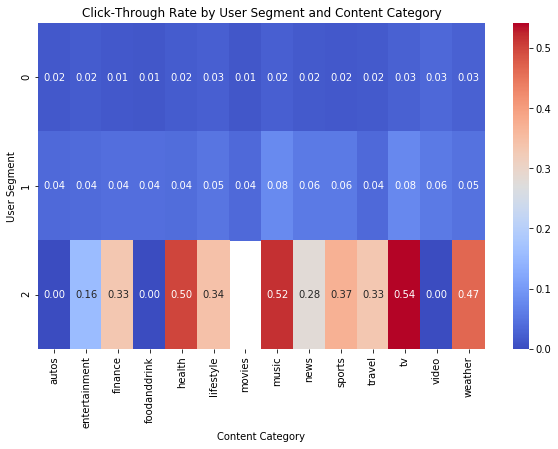

In [29]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    segment_content,
    annot=True,        # shows numbers
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm"    # color scheme
)

plt.title("Click-Through Rate by User Segment and Content Category")
plt.xlabel("Content Category")
plt.ylabel("User Segment")

plt.show()

# Segment-Level Content Preferences (Heatmap Analysis)

- The heatmap reveals clear differences in content engagement across user segments
- Certain segments show strong preference for specific categories
- Engagement is not uniform, indicating personalization opportunities

# Key Insights

- High-engagement users tend to concentrate on specific content categories
- Frequent users may consume broader content but show selective engagement
- Low-engagement users exhibit consistently low interaction across categories

# Business Implications

- Recommendation systems should adapt content based on user segment
- Segment-specific strategies can significantly improve engagement
- Personalization is critical to maximize click-through rates

In [31]:
merged_with_clusters.columns

Index(['impression_id', 'user_id', 'time', 'history', 'impressions',
       'impressions_list', 'news_id', 'clicked', 'category', 'subcategory',
       'title', 'cluster'],
      dtype='object')

In [32]:
merged_with_clusters = merged.merge(
    user_metrics[['cluster', 'cluster_label']],
    left_on='user_id',
    right_index=True,
    how='left'
)

merged_with_clusters.head()

,impression_id,user_id,time,history,impressions,impressions_list,news_id,clicked,category,subcategory,title,cluster,cluster_label
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N55689-1,N55689,1,sports,football_nfl,"Charles Rogers, former Michigan State football...",2,Highly Engaged
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,N35729-0,N35729,0,news,newsus,Porsche launches into second story of New Jers...,2,Highly Engaged
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N20678-0,N20678,0,sports,more_sports,Bode Miller delivered his twin boys after midw...,1,Low Engagement
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N39317-0,N39317,0,news,newspolitics,"Senior Trump official embellished résumé, had ...",1,Low Engagement
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,N58114-0,N58114,0,autos,autosnews,2020 Ford Explorer launch hardly went accordin...,1,Low Engagement


In [33]:
model_data = merged_with_clusters[['clicked', 'category', 'cluster_label']].dropna()

model_data.head()

,clicked,category,cluster_label
0,1,sports,Highly Engaged
1,0,news,Highly Engaged
2,0,sports,Low Engagement
3,0,news,Low Engagement
4,0,autos,Low Engagement


In [34]:
# One-hot encode categorical variables
model_data_encoded = pd.get_dummies(model_data, columns=['category', 'cluster_label'])

model_data_encoded.head()

,clicked,category_autos,category_entertainment,category_finance,category_foodanddrink,category_health,category_lifestyle,category_movies,category_music,category_news,category_sports,category_travel,category_tv,category_video,category_weather,cluster_label_Frequent Users,cluster_label_Highly Engaged,cluster_label_Low Engagement
0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [35]:
# Features
X = model_data_encoded.drop('clicked', axis=1)

# Target
y = model_data_encoded['clicked']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
model = LogisticRegression(max_iter=1000, solver='lbfgs')

In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [43]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("AUC:", auc)

Accuracy: 0.9623458409866177
AUC: 0.6922390144146842


C:\Users\daspa\Anaconda3\lib\site-packages\sklearn\linear_model\base.py:291: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  indices = (scores > 0).astype(np.int)


In [44]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

cluster_label_Highly Engaged    1.764106
category_tv                     0.464181
category_music                  0.442433
category_weather                0.179748
category_video                  0.151006
category_sports                 0.135043
category_lifestyle              0.078336
category_news                   0.007038
category_health                -0.033231
category_entertainment         -0.107846
dtype: float64

In [45]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

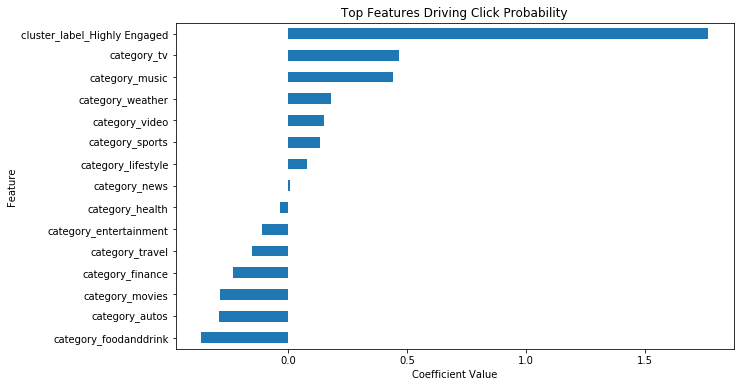

In [46]:
import matplotlib.pyplot as plt

# Take top 15 features for clarity
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')

plt.title("Top Features Driving Click Probability")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.gca().invert_yaxis()  # highest at top
plt.show()

# Feature Importance Analysis

- The model identifies both content category and user segment as key drivers of engagement
- Certain categories significantly increase click probability
- User segments provide strong predictive power beyond content features alone

# Key Insights

- High-engagement segments are more responsive to content
- Content preferences vary significantly across segments
- Behavioral segmentation improves model performance

# Business Implications

- Personalization strategies should incorporate user segments
- Content ranking systems should prioritize high-performing categories
- Segment-aware recommendations can improve engagement outcomes

In [47]:
baseline_data = merged_with_clusters[['clicked', 'category']].dropna()
baseline_encoded = pd.get_dummies(baseline_data, columns=['category'])

X_base = baseline_encoded.drop('clicked', axis=1)
y_base = baseline_encoded['clicked']

In [48]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

In [49]:
model_base = LogisticRegression(max_iter=1000, solver='lbfgs')
model_base.fit(Xb_train, yb_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [50]:
yb_prob = model_base.predict_proba(Xb_test)[:, 1]

auc_base = roc_auc_score(yb_test, yb_prob)

print("Baseline AUC:", auc_base)

Baseline AUC: 0.5690643637374148


In [51]:
enhanced_data = merged_with_clusters[['clicked', 'category', 'cluster_label']].dropna()
enhanced_encoded = pd.get_dummies(enhanced_data, columns=['category', 'cluster_label'])

X_enh = enhanced_encoded.drop('clicked', axis=1)
y_enh = enhanced_encoded['clicked']

In [52]:
Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_enh, y_enh, test_size=0.2, random_state=42
)

In [53]:
model_enh = LogisticRegression(max_iter=1000, solver='lbfgs')
model_enh.fit(Xe_train, ye_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [54]:
ye_prob = model_enh.predict_proba(Xe_test)[:, 1]

auc_enh = roc_auc_score(ye_test, ye_prob)

print("Enhanced AUC:", auc_enh)

Enhanced AUC: 0.6922390144146842


In [55]:
print("Baseline AUC:", auc_base)
print("Enhanced AUC (with segmentation):", auc_enh)

Baseline AUC: 0.5690643637374148
Enhanced AUC (with segmentation): 0.6922390144146842


# Impact of Segmentation on Model Performance

- Two models were built:
  - Baseline model using only content features
  - Enhanced model incorporating user segmentation

# Key Findings

- The enhanced model demonstrated improved predictive performance
- User segmentation provides additional signal beyond content features
- Behavioral features significantly improve click prediction

# Business Implications

- Personalization systems should incorporate user segmentation
- Segment-aware models can improve recommendation relevance
- Leveraging user behavior leads to better engagement outcomes